In [1]:
import torch 
from torch import nn 


In [2]:
# if torch.backends.mps.is_available():
#     device = torch.device("mps")
# elif torch.cuda.is_available():
#     device = torch.device("cuda")
# else:
#     device = torch.device("cpu")

# print(f"Using device: {device}")
device = "cpu"

from timeit import default_timer as timer
def print_train_time(start : float , end : float  , device : torch.device = None ) : 
    total_time = end-start 
    print(f"Train time on {device} : {total_time:.3f} seconds ")
    return total_time 

In [3]:
import requests 
import zipfile 
from pathlib import Path 


data_path = Path("data/")
image_path = data_path / "IndustryBiscuit_Folders"



In [4]:
image_path

PosixPath('data/IndustryBiscuit_Folders')

# Data preperation & exploration 

In [5]:
import os 
def walk_through_dir(dir_path) : 
    """Walks through dir_path returning its contents."""
    for dirpath , dirnames , filenames in os.walk(dir_path) : 
        print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

In [6]:
walk_through_dir(image_path)

There are 3 directories and 1 images in 'data/IndustryBiscuit_Folders'.
There are 2 directories and 1 images in 'data/IndustryBiscuit_Folders/valid'.
There are 0 directories and 280 images in 'data/IndustryBiscuit_Folders/valid/ok'.
There are 0 directories and 278 images in 'data/IndustryBiscuit_Folders/valid/nok'.
There are 2 directories and 1 images in 'data/IndustryBiscuit_Folders/test'.
There are 0 directories and 300 images in 'data/IndustryBiscuit_Folders/test/ok'.
There are 0 directories and 300 images in 'data/IndustryBiscuit_Folders/test/nok'.
There are 2 directories and 1 images in 'data/IndustryBiscuit_Folders/train'.
There are 0 directories and 1300 images in 'data/IndustryBiscuit_Folders/train/ok'.
There are 0 directories and 1300 images in 'data/IndustryBiscuit_Folders/train/nok'.


In [7]:
train_dir = image_path /"train"
test_dir = image_path/"test"

train_dir , test_dir 

(PosixPath('data/IndustryBiscuit_Folders/train'),
 PosixPath('data/IndustryBiscuit_Folders/test'))

# Visualizing an Image

data/IndustryBiscuit_Folders/train/nok/0063.jpg
nok
Random image path: data/IndustryBiscuit_Folders/train/nok/0063.jpg
Image class: nok
Image height: 256
Image width: 256


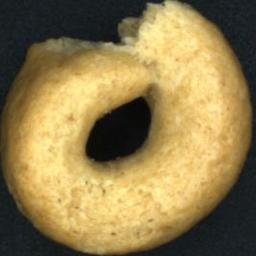

In [8]:
import random 
from PIL import Image 

random.seed(42)
image_path_list = list(image_path.glob("*/*/*.jpg"))

random_image_path = random.choice(image_path_list)
print(random_image_path)

image_class = random_image_path.parent.stem 
print(image_class)

img = Image.open(random_image_path)

print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img


(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

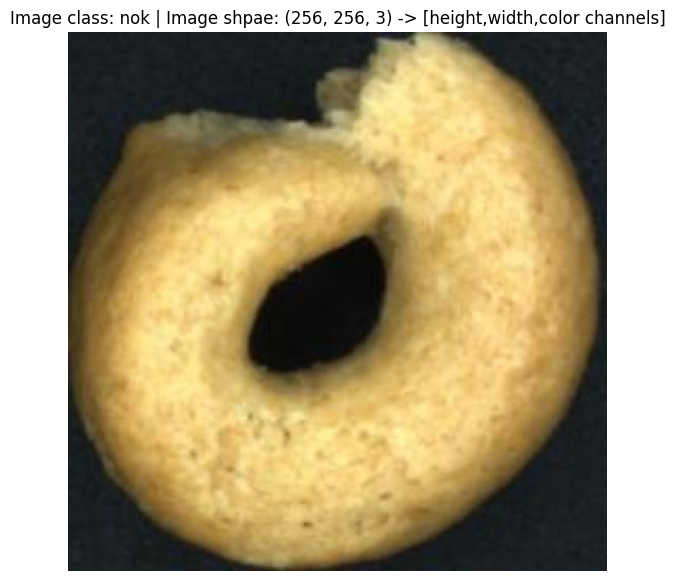

In [9]:
# Visualize using matplotlib 
import numpy as np 
import matplotlib.pyplot as plt 

img_as_array = np.asarray(img)
plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shpae: {img_as_array.shape} -> [height,width,color channels]")
plt.axis(False)

# Transforming Data

In [10]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets , transforms  
import torchvision 


In [11]:

weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
weights


EfficientNet_B0_Weights.IMAGENET1K_V1

In [12]:
auto_transforms = weights.transforms()
auto_transforms


# from torchvision import transforms

# normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                                  std=[0.229, 0.224, 0.225])
# manual_tranforms = transforms.Compose([
#     transforms.Resize((224,224)) , 
#     transforms.ToTensor() , 
#     normalize
    
# ])


normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])


train_transform = transforms.Compose([
    transforms.Resize((224,224)) , 
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    normalize
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])


In [13]:
train_transform(img).shape

torch.Size([3, 224, 224])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.2885156].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.2489083].


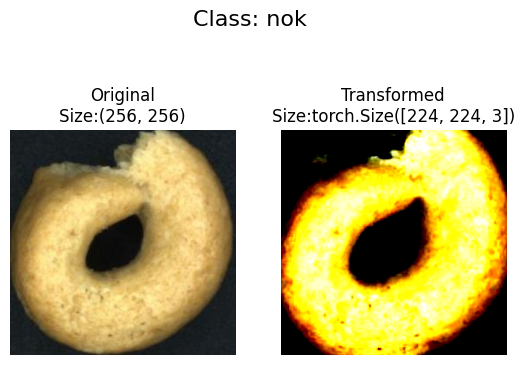

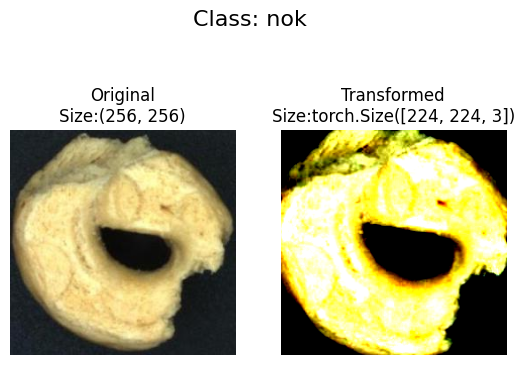

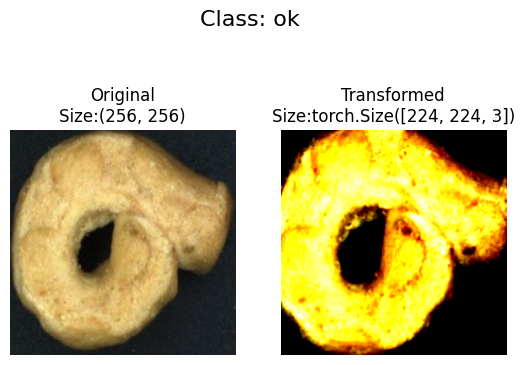

In [14]:
def plot_transformed_images(image_paths : list , transform , n=3 , seed=None) : 
    
    if seed : 
        random.seed(seed)
    random_image_paths = random.sample(image_paths , k = n  ) 
    for image_path in random_image_paths : 
        with Image.open(image_path ) as f : 
            fig ,ax = plt.subplots(nrows = 1 , ncols = 2 )
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nSize:{f.size}")
            ax[0].axis(False)

            transformed_image = transform(f).permute(1,2,0)
            ax[1].imshow(transformed_image)
            ax[1].set_title(f"Transformed\nSize:{transformed_image.shape}")
            ax[1].axis(False)
            
            fig.suptitle(f"Class: {image_path.parent.stem}" , fontsize = 16)


plot_transformed_images(image_paths = image_path_list , transform = auto_transforms , n=3 , seed = 42)
    
        
    

# Loading image data using `ImageFolder`

In [15]:
from torchvision import datasets 
train_data = datasets.ImageFolder(root=train_dir ,
                                  transform=train_transform ,
                                  target_transform=None)
test_data = datasets.ImageFolder(root=test_dir ,
                                  transform=test_transform )

train_data , test_data 

(Dataset ImageFolder
     Number of datapoints: 2600
     Root location: data/IndustryBiscuit_Folders/train
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 Dataset ImageFolder
     Number of datapoints: 600
     Root location: data/IndustryBiscuit_Folders/test
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ))

In [16]:
class_names = train_data.classes
class_names

['nok', 'ok']

In [17]:
class_dict = train_data.class_to_idx
class_dict

{'nok': 0, 'ok': 1}

In [18]:
len(train_data) , len(test_data)

(2600, 600)

In [19]:
train_data.samples[0]

('data/IndustryBiscuit_Folders/train/nok/0001.jpg', 0)

In [20]:
train_data.targets[2000:2020]

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

In [21]:
train_data[0]

(tensor([[[-1.6384, -1.5870, -1.5528,  ..., -1.7412, -1.7069, -1.6898],
          [-1.7069, -1.6555, -1.6213,  ..., -1.7069, -1.7069, -1.7069],
          [-1.7069, -1.6727, -1.6555,  ..., -1.7240, -1.7412, -1.7412],
          ...,
          [-1.6727, -1.6898, -1.6727,  ..., -1.6727, -1.6555, -1.6213],
          [-1.6555, -1.6555, -1.6384,  ..., -1.6727, -1.6555, -1.6213],
          [-1.6213, -1.5870, -1.5870,  ..., -1.6898, -1.6555, -1.6384]],
 
         [[-1.4230, -1.3704, -1.3354,  ..., -1.5630, -1.5280, -1.5105],
          [-1.4930, -1.4405, -1.4055,  ..., -1.5280, -1.5280, -1.5280],
          [-1.4930, -1.4580, -1.4405,  ..., -1.5455, -1.5630, -1.5630],
          ...,
          [-1.4405, -1.4580, -1.4405,  ..., -1.4930, -1.4755, -1.4405],
          [-1.4230, -1.4230, -1.4055,  ..., -1.4930, -1.4755, -1.4405],
          [-1.3880, -1.3529, -1.3529,  ..., -1.5105, -1.4755, -1.4580]],
 
         [[-1.0550, -1.0027, -0.9678,  ..., -1.2816, -1.2467, -1.2293],
          [-1.1247, -1.0724,

In [22]:
img , label = train_data[0][0] , train_data[0][1]
print(img.shape)
print(img.dtype)
print(label)
print(f"lable type {type(label)}")

torch.Size([3, 224, 224])
torch.float32
0
lable type <class 'int'>


In [23]:
class_names[label]

'nok'

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.2489083].


torch.Size([3, 224, 224])
torch.Size([224, 224, 3])


Text(0.5, 1.0, 'nok')

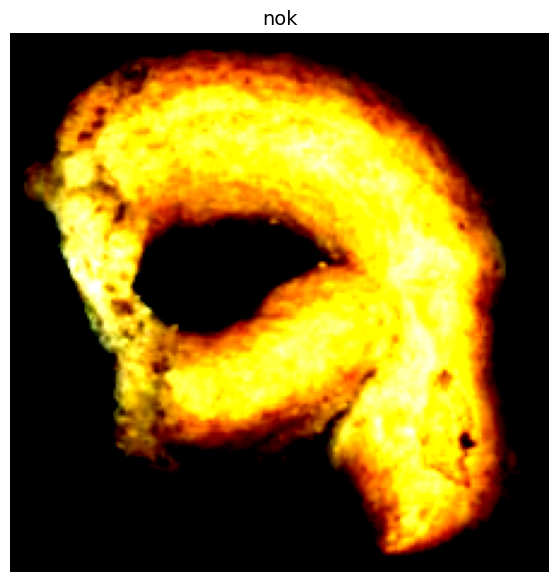

In [24]:
img_premute = img.permute(1,2,0)
print(img.shape)
print(img_premute.shape)
plt.figure(figsize=(10,7))
plt.imshow(img_premute)
plt.axis(False)
plt.title(class_names[label] , fontsize=14)

# Trun loaded images into `DataLoader`

In [25]:
from torch.utils.data import DataLoader
BATCH_SIZE = 32 

train_dataloader = DataLoader(dataset= train_data ,
                              batch_size= BATCH_SIZE ,
                              num_workers=  1, #os.cpu_count() #number of cpus dedicated  
                              shuffle= True )

test_dataloader = DataLoader(dataset= test_data ,
                              batch_size= BATCH_SIZE ,
                              num_workers=  1, #os.cpu_count() 
                              shuffle= False )

train_dataloader , test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x151294290>,
 <torch.utils.data.dataloader.DataLoader at 0x151205220>)

In [26]:
len(train_dataloader) , len(test_dataloader) # len(train)/BATCH_SIZE


(82, 19)

In [27]:
img , label = next(iter(train_dataloader))
print(f"Image shape : {img.shape} ->[batch_size , color_channels , height , width]")
print(f"Label shape: {label.shape}")

Image shape : torch.Size([32, 3, 224, 224]) ->[batch_size , color_channels , height , width]
Label shape: torch.Size([32])


## Create a function to display random images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9980307..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.4110641].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.4285715].


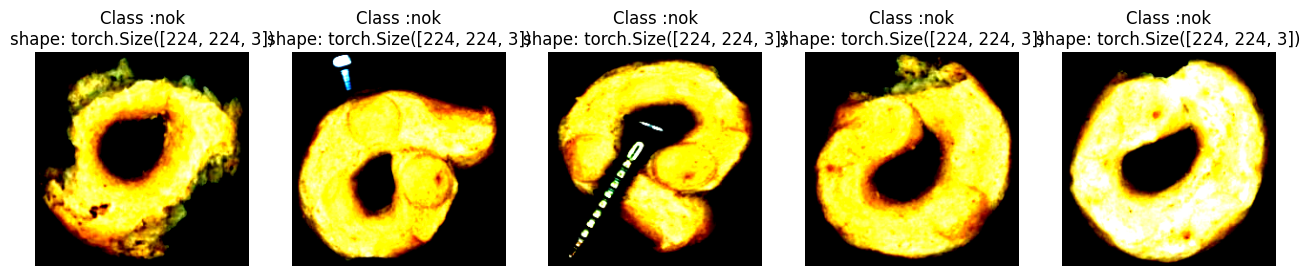

In [28]:
from typing import List


def display_random_images(dataset : torch.utils.data.Dataset ,
                          classes: List[str] = None ,
                          n: int = 10 ,
                          display_shape : bool = True ,
                          seed : int = None   ) : 
    if n >= 10 : 
        n = 10 
        display_shape = False 

    if seed : 
        random.seed(seed)

    random_samples_idx = random.sample(range(len(dataset)) , k = n )

    plt.figure(figsize=(16,8))
    
    for i , targ_sample in enumerate(random_samples_idx) : 
        targ_image , targ_label = dataset[targ_sample][0] , dataset[targ_sample][1]

        targ_image_permuted = targ_image.permute(1, 2, 0 )

        plt.subplot(1, n , i+1 )
        plt.imshow(targ_image_permuted)
        plt.axis(False)
        if classes : 
            title = f"Class :{classes[targ_label]}"
            if display_shape : 
               title = title + f"\nshape: {targ_image_permuted.shape}"
            plt.title(title)
        


display_random_images(dataset = train_data , classes=class_names , seed = None , display_shape = True , n=5 )


# Data Augmentation : trivialaugment

In [29]:
import torchvision

# train_transform = transforms.Compose([
#     transforms.Resize(size=(224 , 224 )) , 
#     transforms.TrivialAugmentWide(num_magnitude_bins=31) , # intensity (0,31)
#     transforms.ToTensor()
# ])

# test_transform = transforms.Compose([
#     transforms.Resize(size=(224 , 224 )) , 
#     transforms.ToTensor()
# ])



weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT 

pretrained_model = torchvision.models.efficientnet_b0(weights=weights).to(device)

pretrained_model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          

### Model summary 

In [30]:
from torchinfo import summary 

summary(model=pretrained_model , 
        input_size = (1,3,224,224 ) , 
        col_names=["input_size","output_size","num_params" , "trainable"] , 
        col_width=20 , 
        row_settings=["var_names"]
       ) 

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   True
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   True
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   True
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    864                  True
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    64                   True
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 16, 112,

### Feature extractor model: Freezing the base model and changing the output layer to suit our needs 

### model 
* features 
* avgpool 
* classifier

In [31]:
from torch import nn 

for param in pretrained_model.features.parameters() :
    param.requires_grad = False 

    
torch.manual_seed(42)
torch.cuda.manual_seed(42)

for param in pretrained_model.features[-1].parameters():
    param.requires_grad = True


pretrained_model.classifier = nn.Sequential(
    nn.Dropout(p=0.2 , inplace = True ) , 
    nn.Linear(in_features = 1280 , 
             out_features = len(class_names) 
             ).to(device)
)

In [32]:
summary(model=pretrained_model , 
        input_size = (1,3,224,224 ) , 
        col_names=["input_size","output_size","num_params" , "trainable"] , 
        col_width=20 , 
        row_settings=["var_names"]
       )  

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 2]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   Partial
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1,

In [34]:

    
def train_step( model :  torch.nn.Module , 
                dataloader :  torch.utils.data.DataLoader , 
                loss_fn : torch.nn.Module , 
                optimizer : torch.optim.Optimizer , 
                accuracy_fn , 
                device : torch.device = device ) : 
    
    model.train()

    train_loss , train_acc = 0,  0
    
    for batch, (X,y) in enumerate(dataloader) : 
        
        X,y = X.to(device) , y.to(device)
        
        y_pred = model(X)
        
        loss = loss_fn(y_pred , y)
        train_loss += loss.item()
        train_acc += accuracy_fn(y_true = y , y_pred = torch.softmax(y_pred, dim=1).argmax(dim=1) )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        # if batch % 400 == 0 : 
            # print(f"Looked at {batch * len(X)} / {len(train_dataloader.dataset )} samples . ")

    train_loss = train_loss/ len(dataloader)
    train_acc = train_acc /  len(dataloader)
    # print(f"\nTrain Loss:{train_loss:.5f} | Train Acc:{train_acc:.3f}" )

    return train_loss , train_acc


In [35]:

def test_step(  model :  torch.nn.Module , 
                dataloader :  torch.utils.data.DataLoader , 
                loss_fn : torch.nn.Module , 
                optimizer : torch.optim.Optimizer , 
                accuracy_fn , 
                device : torch.device = device ): 
    
    test_loss , test_acc = 0, 0 
    
    model.eval()
    
    with torch.inference_mode() : 
        for batch, (X_test, y_test) in enumerate(dataloader): 
            X_test , y_test = X_test.to(device) , y_test.to(device)
            test_pred = model(X_test)

            test_loss += loss_fn(test_pred,y_test).item()
            test_pred_labels = test_pred.argmax(dim=1)
            test_acc += ((test_pred_labels == y_test).sum().item()/len(test_pred_labels))
            # test_acc += accuracy_fn(y_true= y_test , y_pred = torch.softmax(test_pred, dim=1).argmax(dim=1) )

        test_loss = test_loss / len(dataloader)
        test_acc = test_acc / len(dataloader)
        # print(f"\nTest Loss: {test_loss:.5f} | Test Acc: {test_acc:.3f}")

    return test_loss , test_acc


In [37]:

image_batch , label_batch = next(iter(train_dataloader))
image_batch.shape , label_batch.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

In [38]:
pretrained_model(image_batch.to(device))

tensor([[-0.0564,  0.0924],
        [-0.1441, -0.0337],
        [-0.3434, -0.1052],
        [-0.0536,  0.1105],
        [-0.5998, -0.2359],
        [ 0.1550, -0.0106],
        [-0.4565,  0.0854],
        [-0.2889,  0.1098],
        [-0.2698, -0.0627],
        [ 0.0929, -0.4666],
        [-0.3383, -0.0146],
        [ 0.1194,  0.0474],
        [-0.1190,  0.0922],
        [-0.1648,  0.0111],
        [-0.1100, -0.0390],
        [-0.1824,  0.0115],
        [ 0.0884,  0.2641],
        [ 0.1820,  0.0474],
        [-0.2442, -0.2605],
        [-0.1268,  0.1856],
        [-0.3064,  0.0491],
        [-0.1419,  0.1114],
        [ 0.0638, -0.1473],
        [-0.0470,  0.0145],
        [ 0.0060,  0.0691],
        [-0.0487, -0.2168],
        [-0.2028, -0.1964],
        [-0.0269,  0.0394],
        [-0.0349,  0.0175],
        [-0.2452, -0.1324],
        [-0.5862,  0.1008],
        [-0.2569,  0.3967]], grad_fn=<AddmmBackward0>)

# Train & Test

In [40]:

def accuracy_fn(y_true , y_pred ) : 
    correct = torch.eq(y_true, y_pred ).sum().item()
    acc = (correct/len(y_pred)) 
    return acc 

loss_fn = nn.CrossEntropyLoss() 
optimizer = torch.optim.Adam(params=pretrained_model.parameters(),
                             lr=0.001)


In [41]:
epoch_count=[]
train_loss_values=[]
test_loss_values=[]
results = {"train_loss": [] ,
           "test_loss": [] ,
           "train_acc":[] ,
           "test_acc": []}


In [42]:
from tqdm import tqdm

epochs = 4

# min_loss = 1000 
# min_epoch = 0 


pretrained_model.to(device)

for epoch in  tqdm(range(epochs)) : 
    

    train_loss , train_acc = train_step(model = pretrained_model , 
                dataloader =  train_dataloader, 
                loss_fn = loss_fn , 
                optimizer = optimizer, 
               accuracy_fn = accuracy_fn, 
                device = device)

    test_loss , test_acc = test_step(model = pretrained_model , 
                dataloader =  test_dataloader, 
                loss_fn = loss_fn , 
                optimizer = optimizer, 
                accuracy_fn = accuracy_fn, 
                device = device)

    print(f"Epoch: {epoch} | Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

    results["train_loss"].append(train_loss)
    results["test_loss"].append(test_loss)
    results["train_acc"].append(train_acc)
    results["test_acc"].append(test_acc)
    


 25%|███████████████████████▌                                                                      | 1/4 [03:23<10:10, 203.54s/it]

Epoch: 0 | Train loss: 0.2790 | Train acc: 0.8796 | Test loss: 0.1678 | Test acc: 0.9232


 50%|███████████████████████████████████████████████                                               | 2/4 [06:50<06:50, 205.34s/it]

Epoch: 1 | Train loss: 0.1426 | Train acc: 0.9413 | Test loss: 0.0747 | Test acc: 0.9792


 75%|██████████████████████████████████████████████████████████████████████▌                       | 3/4 [10:15<03:25, 205.35s/it]

Epoch: 2 | Train loss: 0.0806 | Train acc: 0.9710 | Test loss: 0.0654 | Test acc: 0.9786


100%|██████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [13:46<00:00, 206.55s/it]

Epoch: 3 | Train loss: 0.0620 | Train acc: 0.9779 | Test loss: 0.0731 | Test acc: 0.9737


In [43]:
# 32 + 2 

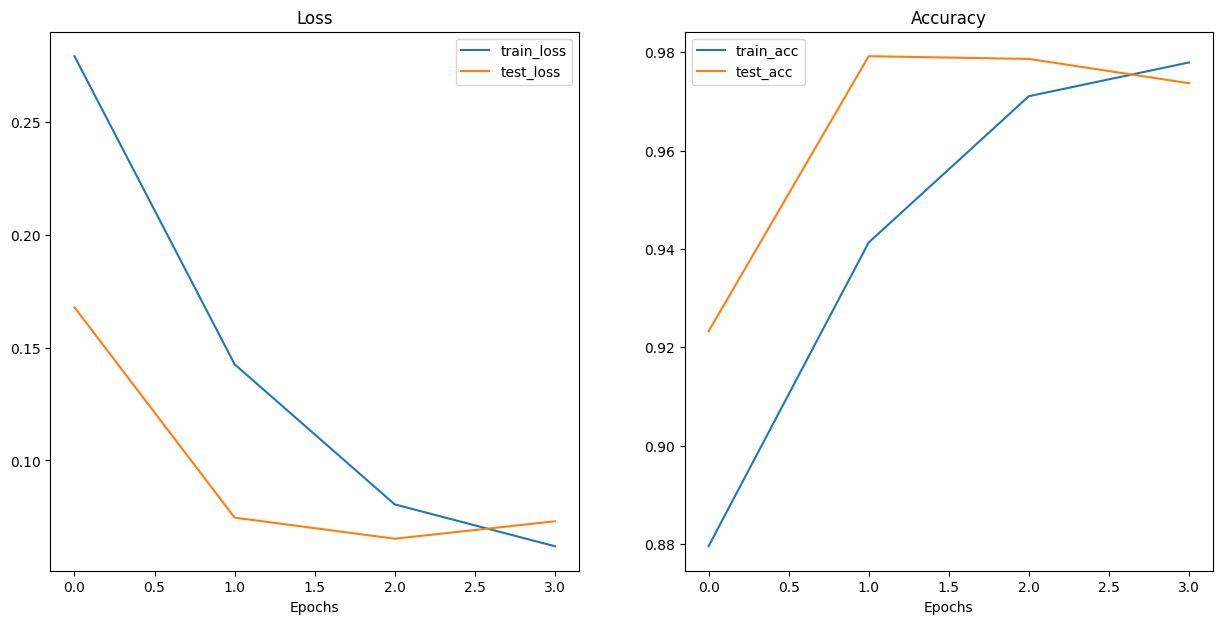

In [49]:

from typing import List, Dict

def plot_loss_curves(results : Dict[str, List[float]] ): 
    train_loss = results["train_loss"]
    test_loss = results["test_loss"]
    train_acc = results["train_acc"]
    test_acc = results["test_acc"]
    
    epochs = range(len(results["train_loss"]))

    plt.figure(figsize=(15,7))


    plt.subplot(1,2,1)
    plt.plot(epochs , train_loss , label="train_loss")
    plt.plot(epochs , test_loss , label="test_loss")
    plt.title("Loss")
    plt.xlabel("Epochs")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(epochs , train_acc , label="train_acc")
    plt.plot(epochs , test_acc , label="test_acc")
    plt.title("Accuracy")
    plt.xlabel("Epochs")
    plt.legend()


plot_loss_curves(results)
    

In [50]:
torch.manual_seed(42)

def eval_model( model : torch.nn.Module , 
                data_loader : torch.utils.data.DataLoader , 
                loss_fn : torch.nn.Module , 
                accuracy_fn , 
                 device : torch.device = device ) : 
    loss , acc = 0 , 0 
    model.to(device)
    model.eval()
    with torch.inference_mode() : 
        for X, y in data_loader : 
            X , y = X.to(device) , y.to(device)
            y_pred = model(X)
            loss+= loss_fn(y_pred , y)
            acc+= accuracy_fn(y_true= y , y_pred = y_pred.argmax(dim=1))
        loss/=len(data_loader)
        acc/=len(data_loader)


        return {"model_name" : model.__class__.__name__ , 
                 "model_loss" : loss.item() , 
                 "model_acc" : acc}



pretrained_model_reuslts = eval_model(model=  pretrained_model
                             , data_loader = test_dataloader 
                             , loss_fn = loss_fn 
                             , accuracy_fn = accuracy_fn )
pretrained_model_reuslts

{'model_name': 'EfficientNet',
 'model_loss': 0.07307334989309311,
 'model_acc': 0.9736842105263158}

In [51]:
def make_predictions(model: torch.nn.Module , 
                     data : list , 
                     device : torch.device = device ) : 
    pred_probs =[]
    model.to(device)
    model.eval()

    with torch.inference_mode()  : 
        for sample in data : 
            sample = sample.unsqueeze(0).to(device)
            pred_logit = model(sample)
            pred_prob = torch.softmax(pred_logit, dim=1 ).argmax(dim=1).squeeze(0)
            pred_probs.append(pred_prob.cpu())
            
    return torch.stack(pred_probs)
    


In [52]:
import random 
# random.seed(42)
test_samples = []
test_labels =[]

for sample , label in random.sample(list(test_data) , k = 9 ) : 
    test_samples.append(sample)
    test_labels.append(label)

In [54]:
pred_probs = make_predictions(model = pretrained_model , data = test_samples )
pred_probs

tensor([0, 1, 0, 1, 1, 0, 1, 0, 0])

In [55]:
test_labels

[0, 1, 0, 1, 1, 0, 1, 0, 0]

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0151556..2.4285715].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049

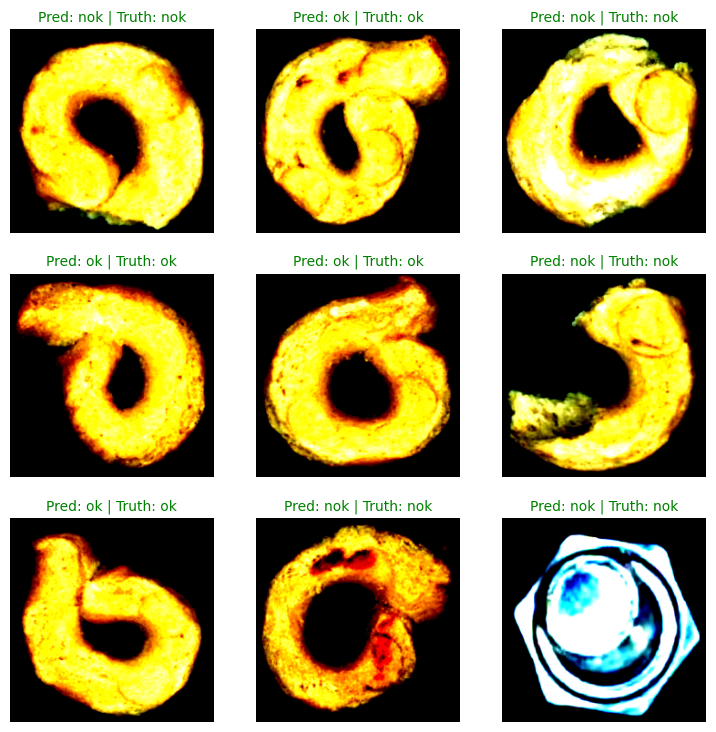

In [56]:
plt.figure(figsize=(9,9))
nrows = 3 
ncols = 3 

for i, sample in enumerate(test_samples) : 
    plt.subplot(nrows , ncols , i+1 )
    plt.imshow(sample.squeeze().permute(1, 2, 0))
    pred_label = class_names[pred_probs[i]]
    truth_label = class_names[test_labels[i]]

    title_text = f"Pred: {pred_label} | Truth: {truth_label}"

    if pred_label == truth_label : 
        plt.title(title_text , fontsize = 10 , c="g")
    else : 
        plt.title(title_text , fontsize = 10 , c="r")

    

    plt.axis(False)

In [58]:
from tqdm import tqdm

y_preds = []
pretrained_model.eval()
with torch.inference_mode() : 
    for X,y in   tqdm(test_dataloader,desc="Making predictions...") : 
        X , y = X.to(device) , y.to(device)
        y_logits = pretrained_model(X)
        y_pred = torch.softmax(y_logits, dim=1 ).argmax(dim=1).squeeze(0)
        y_preds.append(y_pred)

print(len(y_preds[0]))
y_pred_tensor = torch.cat(y_preds)
y_pred_tensor

Making predictions...: 100%|██████████████████████████████████████████████████████████████████████| 19/19 [00:39<00:00,  2.09s/it]

32


tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

/var/folders/x0/4xyb0l7x6jq6l77tkdkd_t0w0000gn/T/ipykernel_4617/4265044712.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y_pred_tensor = torch.tensor(y_pred_tensor).to(device)


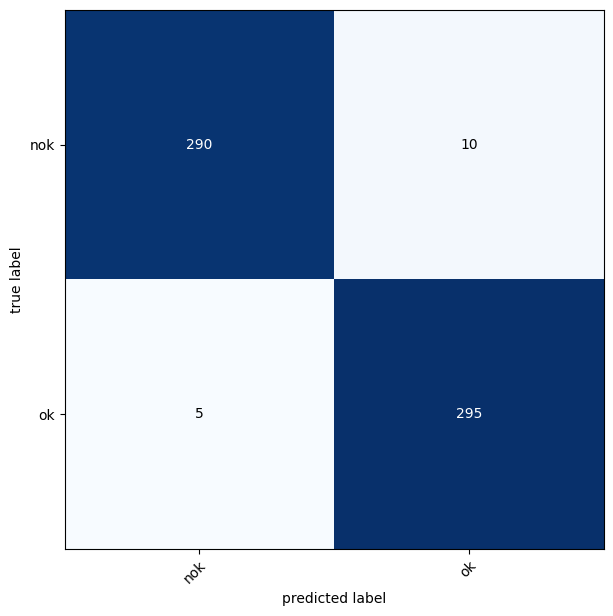

In [59]:
from torchmetrics import ConfusionMatrix 
from mlxtend.plotting import plot_confusion_matrix 
device = "cpu"
# setup confusion matrix 
confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names)).to(device)
y_pred_tensor = torch.tensor(y_pred_tensor).to(device)
targets = torch.tensor(test_data.targets).to(device)

confmat_tensor = confmat(preds = y_pred_tensor , target = targets )

#plot confusion matrix 
fig , ax = plot_confusion_matrix(
    conf_mat = confmat_tensor.numpy() , 
    class_names = class_names , 
    figsize = (10,7)
)


In [60]:
from pathlib import Path 

# create model's directory 
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True , exist_ok = True)
# create model save path 
MODEL_NAME = "biscuit-transfer-learning-model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# save the model state dict 
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj = model_0.state_dict() ,f=  MODEL_SAVE_PATH) ; 


Saving model to: models/biscuit-transfer-learning-model.pth
